In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_excel('/Users/macbook/Desktop/TAXI_PRICE_EXTENSION/PDC 19.xlsx')

In [3]:
df

,OSF_ID,Maternal_Age,Household_Income,Maternal_Education,Edinburgh_Postnatal_Depression_Scale,PROMIS_Anxiety,Gestational_Age_At_Birth,Delivery_Date(converted to month and year),Birth_Length,Birth_Weight,Delivery_Mode,NICU_Stay,Language,Threaten_Life,Threaten_Baby_Danger,Threaten_Baby_Harm
0,1,38.3,200000.0,Masters degree,9.0,13.0,39.71,2020-12-01,49.20,3431.0,Vaginally,No,English,2,3,27
1,2,34.6,200000.0,Undergraduate degree,4.0,17.0,NaN,NaT,NaN,NaN,NaN,NaN,English,2,33,92
2,3,34.3,115000.0,Undergraduate degree,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,French,,,
3,4,28.8,115000.0,Masters degree,9.0,20.0,38.57,2020-12-01,41.00,2534.0,Vaginally,No,French,53,67,54
4,5,36.5,55000.0,Undergraduate degree,14.0,20.0,39.86,2020-10-01,53.34,3714.0,Caesarean-section (c-section),No,English,23,32,71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10767,10768,38.3,115000.0,Undergraduate degree,10.0,18.0,NaN,NaT,NaN,NaN,NaN,NaN,English,54,62,74
10768,10769,29.9,140000.0,Undergraduate degree,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,English,,,
10769,10770,27.7,30000.0,College/trade school,4.0,15.0,NaN,NaT,NaN,NaN,NaN,NaN,French,21,93,76
10770,10771,23.0,30000.0,College/trade school,12.0,19.0,NaN,NaT,NaN,NaN,NaN,NaN,English,65,94,94


In [4]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10772 entries, 0 to 10771
Data columns (total 16 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   OSF_ID                                      10772 non-null  int64         
 1   Maternal_Age                                10661 non-null  float64       
 2   Household_Income                            10521 non-null  float64       
 3   Maternal_Education                          10595 non-null  object        
 4   Edinburgh_Postnatal_Depression_Scale        9598 non-null   float64       
 5   PROMIS_Anxiety                              9566 non-null   float64       
 6   Gestational_Age_At_Birth                    6734 non-null   float64       
 7   Delivery_Date(converted to month and year)  6733 non-null   datetime64[ns]
 8   Birth_Length                                5480 non-null   float64       
 9   Birth_

In [5]:
rows_to_drop= df[(df['PROMIS_Anxiety'].isnull())&(df['Delivery_Date(converted to month and year)'].isnull())&(
    df['Threaten_Life']==' ')&(df['Threaten_Baby_Danger']==' ')&(df['Threaten_Baby_Harm']==' ')].index


df.drop(rows_to_drop, inplace=True)
df.shape

(10292, 16)

In [6]:
df.drop(columns=['OSF_ID','Language'], inplace=True)

In [7]:
df

,Maternal_Age,Household_Income,Maternal_Education,Edinburgh_Postnatal_Depression_Scale,PROMIS_Anxiety,Gestational_Age_At_Birth,Delivery_Date(converted to month and year),Birth_Length,Birth_Weight,Delivery_Mode,NICU_Stay,Threaten_Life,Threaten_Baby_Danger,Threaten_Baby_Harm
0,38.3,200000.0,Masters degree,9.0,13.0,39.71,2020-12-01,49.20,3431.0,Vaginally,No,2,3,27
1,34.6,200000.0,Undergraduate degree,4.0,17.0,NaN,NaT,NaN,NaN,NaN,NaN,2,33,92
3,28.8,115000.0,Masters degree,9.0,20.0,38.57,2020-12-01,41.00,2534.0,Vaginally,No,53,67,54
4,36.5,55000.0,Undergraduate degree,14.0,20.0,39.86,2020-10-01,53.34,3714.0,Caesarean-section (c-section),No,23,32,71
5,38.3,165000.0,Undergraduate degree,3.0,8.0,38.57,2020-06-01,NaN,NaN,NaN,NaN,29,36,33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10766,32.7,85000.0,High school diploma,15.0,27.0,NaN,NaT,NaN,NaN,NaN,NaN,54,64,75
10767,38.3,115000.0,Undergraduate degree,10.0,18.0,NaN,NaT,NaN,NaN,NaN,NaN,54,62,74
10769,27.7,30000.0,College/trade school,4.0,15.0,NaN,NaT,NaN,NaN,NaN,NaN,21,93,76
10770,23.0,30000.0,College/trade school,12.0,19.0,NaN,NaT,NaN,NaN,NaN,NaN,65,94,94


## Mức độ lo lắng của phụ nữ mang thai  

In [8]:
mask_25_38 = (df['Maternal_Age'] >= 25) & (df['Maternal_Age'] <= 38)
mask_over_42 = df['Maternal_Age'] > 42
anxiety_25_38 = df.loc[mask_25_38, 'PROMIS_Anxiety'].mean()
anxiety_over_42 = df.loc[mask_over_42, 'PROMIS_Anxiety'].mean()
print(f"Giá trị trung bình của Anxiety cho nhóm 25-38 tuổi: {anxiety_25_38:.2f}")
print(f"Giá trị trung bình của Anxiety cho nhóm trên 42 tuổi: {anxiety_over_42:.2f}")


Giá trị trung bình của Anxiety cho nhóm 25-38 tuổi: 18.59
Giá trị trung bình của Anxiety cho nhóm trên 42 tuổi: 17.72


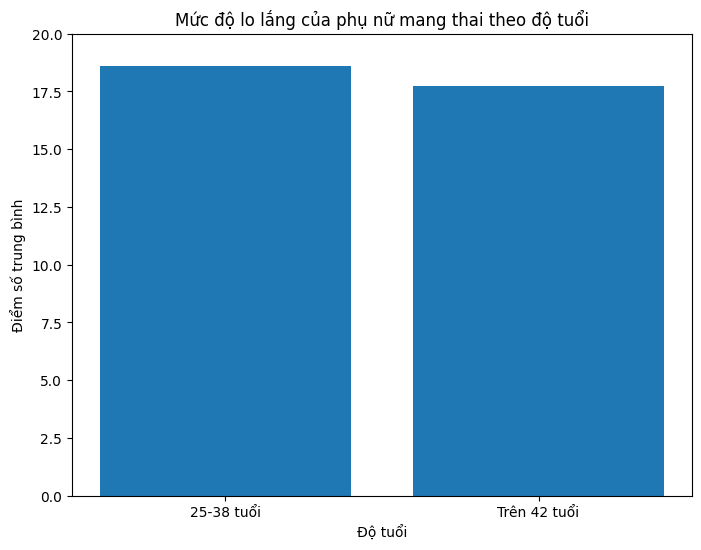

In [9]:
# Vẽ biểu đồ
plt.figure(figsize=(8,6))
labels = ['25-38 tuổi', 'Trên 42 tuổi']
values = [anxiety_25_38, anxiety_over_42]
plt.bar(labels, values)
plt.ylim(0, 20)
plt.title('Mức độ lo lắng của phụ nữ mang thai theo độ tuổi')
plt.xlabel('Độ tuổi')
plt.ylabel('Điểm số trung bình')

plt.show()

## Giải thích biểu đồ trên


## Mức độ trầm cảm của phụ nữ mang thai theo thang edinburgh

In [10]:
mask_25_38 = (df['Maternal_Age'] >= 25) & (df['Maternal_Age'] <= 38)
mask_over_42 = df['Maternal_Age'] > 42
Depression_25_38 = df.loc[mask_25_38, 'Edinburgh_Postnatal_Depression_Scale'].mean()
Depression_over_42 = df.loc[mask_over_42, 'Edinburgh_Postnatal_Depression_Scale'].mean()
print(f"Giá trị trung bình của EDPS cho nhóm 25-38 tuổi: {Depression_25_38:.2f}")
print(f"Giá trị trung bình của EDPS cho nhóm trên 42 tuổi: {Depression_over_42:.2f}")


Giá trị trung bình của EDPS cho nhóm 25-38 tuổi: 10.07
Giá trị trung bình của EDPS cho nhóm trên 42 tuổi: 9.47


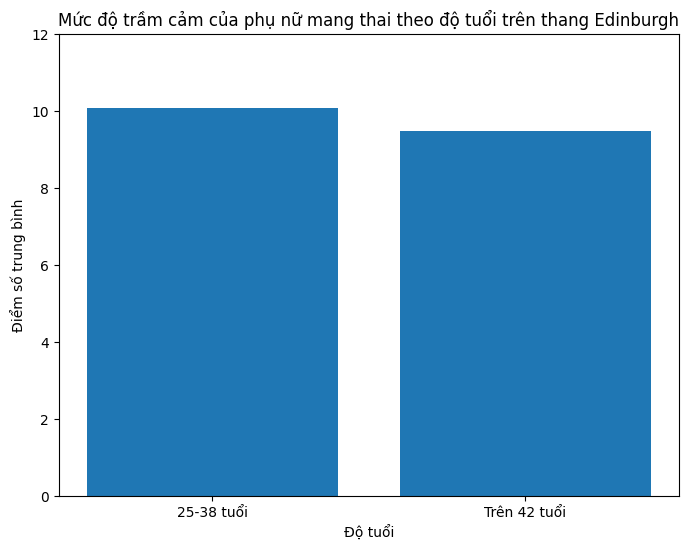

In [11]:
# Vẽ biểu đồ
plt.figure(figsize=(8,6))
labels = ['25-38 tuổi', 'Trên 42 tuổi']
values = [Depression_25_38, Depression_over_42]

plt.bar(labels, values)
plt.ylim(0,12)
plt.title('Mức độ trầm cảm của phụ nữ mang thai theo độ tuổi trên thang Edinburgh')
plt.xlabel('Độ tuổi')
plt.ylabel('Điểm số trung bình')

plt.show()

In [12]:
df_filtered = df.dropna(subset=['Threaten_Life', 'Threaten_Baby_Danger', 'Threaten_Baby_Harm'])

In [13]:
df.dropna(subset=['Threaten_Life', 'Threaten_Baby_Danger', 'Threaten_Baby_Harm'])

,Maternal_Age,Household_Income,Maternal_Education,Edinburgh_Postnatal_Depression_Scale,PROMIS_Anxiety,Gestational_Age_At_Birth,Delivery_Date(converted to month and year),Birth_Length,Birth_Weight,Delivery_Mode,NICU_Stay,Threaten_Life,Threaten_Baby_Danger,Threaten_Baby_Harm
0,38.3,200000.0,Masters degree,9.0,13.0,39.71,2020-12-01,49.20,3431.0,Vaginally,No,2,3,27
1,34.6,200000.0,Undergraduate degree,4.0,17.0,NaN,NaT,NaN,NaN,NaN,NaN,2,33,92
3,28.8,115000.0,Masters degree,9.0,20.0,38.57,2020-12-01,41.00,2534.0,Vaginally,No,53,67,54
4,36.5,55000.0,Undergraduate degree,14.0,20.0,39.86,2020-10-01,53.34,3714.0,Caesarean-section (c-section),No,23,32,71
5,38.3,165000.0,Undergraduate degree,3.0,8.0,38.57,2020-06-01,NaN,NaN,NaN,NaN,29,36,33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10766,32.7,85000.0,High school diploma,15.0,27.0,NaN,NaT,NaN,NaN,NaN,NaN,54,64,75
10767,38.3,115000.0,Undergraduate degree,10.0,18.0,NaN,NaT,NaN,NaN,NaN,NaN,54,62,74
10769,27.7,30000.0,College/trade school,4.0,15.0,NaN,NaT,NaN,NaN,NaN,NaN,21,93,76
10770,23.0,30000.0,College/trade school,12.0,19.0,NaN,NaT,NaN,NaN,NaN,NaN,65,94,94


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10292 entries, 0 to 10771
Data columns (total 14 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   Maternal_Age                                10203 non-null  float64       
 1   Household_Income                            10068 non-null  float64       
 2   Maternal_Education                          10139 non-null  object        
 3   Edinburgh_Postnatal_Depression_Scale        9598 non-null   float64       
 4   PROMIS_Anxiety                              9566 non-null   float64       
 5   Gestational_Age_At_Birth                    6734 non-null   float64       
 6   Delivery_Date(converted to month and year)  6733 non-null   datetime64[ns]
 7   Birth_Length                                5480 non-null   float64       
 8   Birth_Weight                                6078 non-null   float64       
 9   Delivery_Mo

In [15]:
categories = df['Household_Income'].unique()
categories


array([200000., 115000.,  55000., 165000.,     nan,  85000., 190000.,
       140000.,  30000.,  20000.])

In [16]:
df['Household_Income'] = df['Household_Income'].astype('float')

In [17]:
PROMIS_Anxiety = list(map(str, range(0, 30)))
PROMIS_Anxiety 

['0',
 '1',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 '10',
 '11',
 '12',
 '13',
 '14',
 '15',
 '16',
 '17',
 '18',
 '19',
 '20',
 '21',
 '22',
 '23',
 '24',
 '25',
 '26',
 '27',
 '28',
 '29']

In [18]:
import plotly.express as px

categories = df['Household_Income'].unique()

fig = px.histogram(df, x="PROMIS_Anxiety", y="Household_Income", color="Household_Income",
                   histfunc='count',
                   hover_data=df.columns)
fig.update_layout(
    xaxis_title="PROMIS Anxiety",
    yaxis_title="Number of Avrange Household Income"
)

fig.show()

In [19]:
import plotly.express as px

categories = df['Household_Income'].dropna().unique()

fig = px.histogram(df, x="Edinburgh_Postnatal_Depression_Scale", y="Household_Income", color="Household_Income", 
                   histfunc='count',
                   hover_data=df.columns)
fig.update_layout(
    xaxis_title="Edinburgh Postnatal Depression Scale",
    yaxis_title="Number of Avrange Household Income"
)



fig.show()

In [20]:
import pandas as pd

def age_category(age):
    if 25 <= age <= 38:
        return '25-38'
    elif age > 42:
        return 'Over 42'

df['Age_Group'] = df['Maternal_Age'].apply(age_category)

df.head(20)

,Maternal_Age,Household_Income,Maternal_Education,Edinburgh_Postnatal_Depression_Scale,PROMIS_Anxiety,Gestational_Age_At_Birth,Delivery_Date(converted to month and year),Birth_Length,Birth_Weight,Delivery_Mode,NICU_Stay,Threaten_Life,Threaten_Baby_Danger,Threaten_Baby_Harm,Age_Group
0,38.3,200000.0,Masters degree,9.0,13.0,39.71,2020-12-01,49.20,3431.0,Vaginally,No,2,3,27,None
1,34.6,200000.0,Undergraduate degree,4.0,17.0,NaN,NaT,NaN,NaN,NaN,NaN,2,33,92,25-38
3,28.8,115000.0,Masters degree,9.0,20.0,38.57,2020-12-01,41.00,2534.0,Vaginally,No,53,67,54,25-38
4,36.5,55000.0,Undergraduate degree,14.0,20.0,39.86,2020-10-01,53.34,3714.0,Caesarean-section (c-section),No,23,32,71,25-38
5,38.3,165000.0,Undergraduate degree,3.0,8.0,38.57,2020-06-01,NaN,NaN,NaN,NaN,29,36,33,None
6,34.5,200000.0,High school diploma,8.0,15.0,NaN,NaT,NaN,NaN,NaN,NaN,24,30,32,25-38
7,NaN,NaN,NaN,NaN,NaN,38.00,2021-05-01,50.17,2892.0,Caesarean-section (c-section),Yes,,,,None
8,33.1,115000.0,College/trade school,1.0,7.0,40.86,2020-11-01,55.88,4480.0,Vaginally,No,27,76,72,25-38
9,25.8,85000.0,College/trade school,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,50,88,84,25-38
10,28.6,85000.0,Less than high school diploma,20.0,28.0,NaN,NaT,NaN,NaN,NaN,NaN,0,50,98,25-38


In [21]:
figx = px.box(df, x="Age_Group", y="Threaten_Life", color="Age_Group")

figx.show()

In [22]:
figx = px.box(df, x="Age_Group", y="Threaten_Baby_Danger", color="Age_Group")

figx.show()

In [23]:
figy = px.box(df, x="Age_Group", y="Threaten_Baby_Harm", color="Age_Group")

figy.show()

In [24]:
result = df[['Age_Group', 
             'Edinburgh_Postnatal_Depression_Scale',
             'PROMIS_Anxiety', 
             'Threaten_Life',	
             'Threaten_Baby_Danger', 
             'Threaten_Baby_Harm']].dropna()

epds_mean_25_38 = df[df['Age_Group'] == '25-38']['Edinburgh_Postnatal_Depression_Scale'].mean()
epds_mean_Over_42 = df[df['Age_Group'] == 'Over 42']['Edinburgh_Postnatal_Depression_Scale'].mean()
epds_median_25_38 = df[df['Age_Group'] == '25-38']['Edinburgh_Postnatal_Depression_Scale'].median()
epds_median_Over_42 = df[df['Age_Group'] == 'Over 42']['Edinburgh_Postnatal_Depression_Scale'].median()

result['EPDS_Mean'] = result['Age_Group'].apply(lambda x: epds_mean_25_38 if x == '25-38' else epds_mean_Over_42)
result['EPDS_Median'] = result['Age_Group'].apply(lambda x: epds_median_25_38  if x == '25-38' else epds_median_Over_42)

TL_mean_25_38 = result[result['Age_Group'] == '25-38']['Threaten_Life'].mean()
TL_mean_Over_42 = result[result['Age_Group'] == 'Over 42']['Threaten_Life'].mean()

TBD_mean_25_38 = result[result['Age_Group'] == '25-38']['Threaten_Baby_Danger'].mean()
TBD_mean_Over_42 = result[result['Age_Group'] == 'Over 42']['Threaten_Baby_Danger'].mean()

TBH_mean_25_38 = result[result['Age_Group'] == '25-38']['Threaten_Baby_Harm'].mean()
TBH_mean_Over_42 = result[result['Age_Group'] == 'Over 42']['Threaten_Baby_Harm'].mean()

print('1. Giá trị trung bình của Threaten Life ở độ tuổi 25-38 là:', TL_mean_25_38)
print('2. Giá trị trung bình của Threaten Life ở độ tuổi trên 42 là:', TL_mean_Over_42)

print('3. Giá trị trung bình của Threaten Baby Danger ở độ tuổi 25-38 là:', TBD_mean_25_38)
print('4. Giá trị trung bình của Threaten Baby Danger ở độ tuổi trên 42 là:', TBD_mean_Over_42)

print('5. Giá trị trung bình của Threaten Baby Harm ở độ tuổi 25-38 là:', TBH_mean_25_38)
print('6. Giá trị trung bình của Threaten Baby Harm ở độ tuổi trên 42 là:', TBH_mean_Over_42)

1. Giá trị trung bình của Threaten Life ở độ tuổi 25-38 là: 42.14698385726423
2. Giá trị trung bình của Threaten Life ở độ tuổi trên 42 là: 39.60176991150443
3. Giá trị trung bình của Threaten Baby Danger ở độ tuổi 25-38 là: 50.54642553707974
4. Giá trị trung bình của Threaten Baby Danger ở độ tuổi trên 42 là: 46.84070796460177
5. Giá trị trung bình của Threaten Baby Harm ở độ tuổi 25-38 là: 62.47615001820609
6. Giá trị trung bình của Threaten Baby Harm ở độ tuổi trên 42 là: 56.743362831858406
